In [2]:
import scipy.special as sp
import scipy.integrate as integrate
import numpy as np
from matplotlib import pyplot as plt
from scipy.integrate import solve_ivp
from matplotlib import pyplot as plt
from scipy.integrate import simpson

In [35]:


theta_00=9*np.pi/128 #first initial theta that is not zero.
x_0=[theta_00+9*np.pi/(100*128),0] #inital vector [theta_0, omega_0] for each trajectory.
# #contant equal to sqrt(g/l) where l is pendulum length.
n_trajectories=15 #number of trajectories
t=400
omega_0=.25
tt=.25*(np.array(range(0,t,2))) #Make time range into numpy array
F_theta=np.zeros([np.size(tt)]) #Initalize vector
F_omega=np.zeros([np.size(tt)]) #Initalize vector
F_omegadot=np.zeros([np.size(tt)]) #Initalize vector
print(tt)

[ 0.   0.5  1.   1.5  2.   2.5  3.   3.5  4.   4.5  5.   5.5  6.   6.5
  7.   7.5  8.   8.5  9.   9.5 10.  10.5 11.  11.5 12.  12.5 13.  13.5
 14.  14.5 15.  15.5 16.  16.5 17.  17.5 18.  18.5 19.  19.5 20.  20.5
 21.  21.5 22.  22.5 23.  23.5 24.  24.5 25.  25.5 26.  26.5 27.  27.5
 28.  28.5 29.  29.5 30.  30.5 31.  31.5 32.  32.5 33.  33.5 34.  34.5
 35.  35.5 36.  36.5 37.  37.5 38.  38.5 39.  39.5 40.  40.5 41.  41.5
 42.  42.5 43.  43.5 44.  44.5 45.  45.5 46.  46.5 47.  47.5 48.  48.5
 49.  49.5 50.  50.5 51.  51.5 52.  52.5 53.  53.5 54.  54.5 55.  55.5
 56.  56.5 57.  57.5 58.  58.5 59.  59.5 60.  60.5 61.  61.5 62.  62.5
 63.  63.5 64.  64.5 65.  65.5 66.  66.5 67.  67.5 68.  68.5 69.  69.5
 70.  70.5 71.  71.5 72.  72.5 73.  73.5 74.  74.5 75.  75.5 76.  76.5
 77.  77.5 78.  78.5 79.  79.5 80.  80.5 81.  81.5 82.  82.5 83.  83.5
 84.  84.5 85.  85.5 86.  86.5 87.  87.5 88.  88.5 89.  89.5 90.  90.5
 91.  91.5 92.  92.5 93.  93.5 94.  94.5 95.  95.5 96.  96.5 97.  97.5
 98.  

In [36]:
def fx(t,x,omega_0): #define integrator for pendulum ODE to find omega
    return np.array([x[1],-omega_0**2*np.sin(x[0])])

In [37]:
n_trajectories = 15

/opt/anaconda3/lib/python3.9/site-packages/scipy/integrate/_ivp/common.py:39: UserWarning: The following arguments have no effect for a chosen solver: `vectorize`.
  warn("The following arguments have no effect for a chosen solver: {}."
/opt/anaconda3/lib/python3.9/site-packages/scipy/integrate/_ivp/common.py:47: UserWarning: At least one element of `rtol` is too small. Setting `rtol = np.maximum(rtol, 2.220446049250313e-14)`.
  warn("At least one element of `rtol` is too small. "


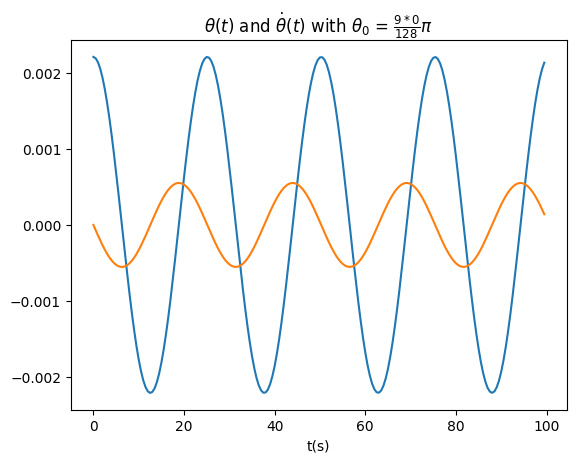

0.0π
Percent Error:
0.056750231071463965


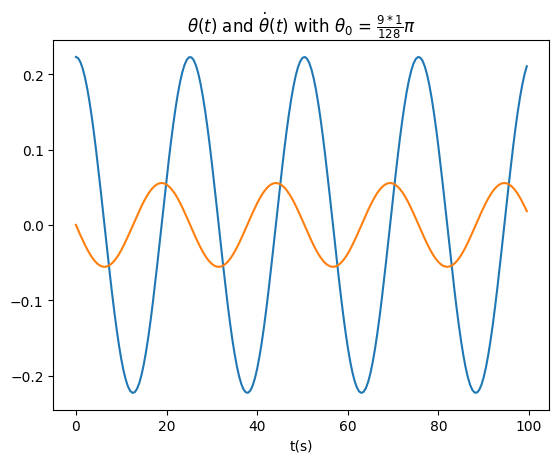

0.0703125π
Percent Error:
0.0006792036585362893


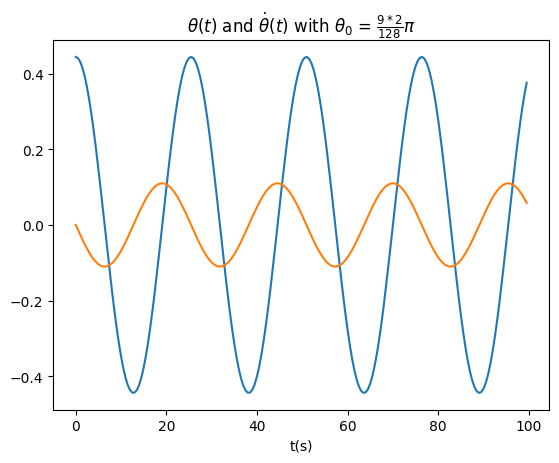

0.140625π
Percent Error:
0.0005736438477221843


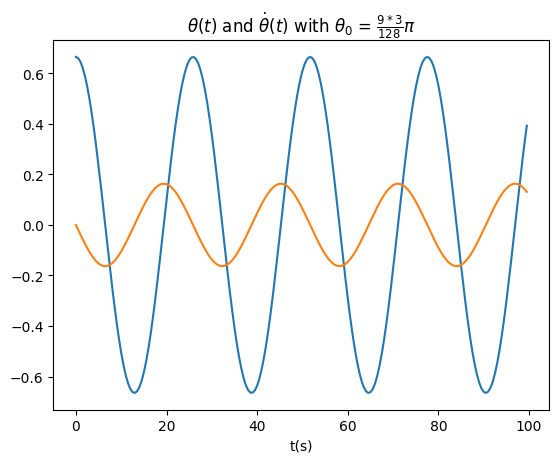

0.2109375π
Percent Error:
0.002183003498364263


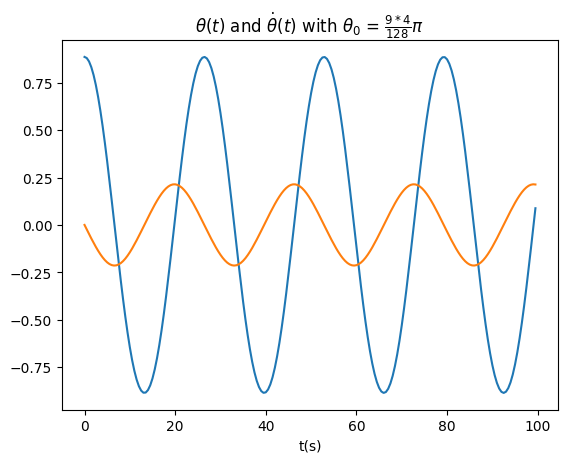

0.28125π
Percent Error:
0.0008854898132587841


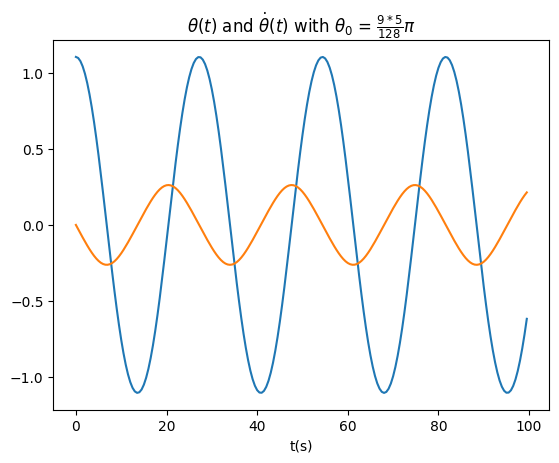

0.3515625π
Percent Error:
0.0004270874666142395


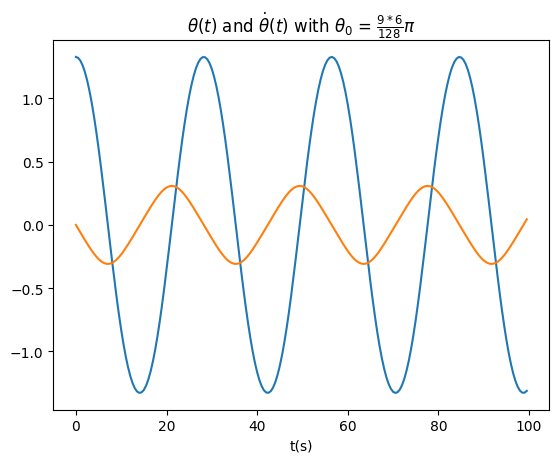

0.421875π
Percent Error:
0.001145663985456214


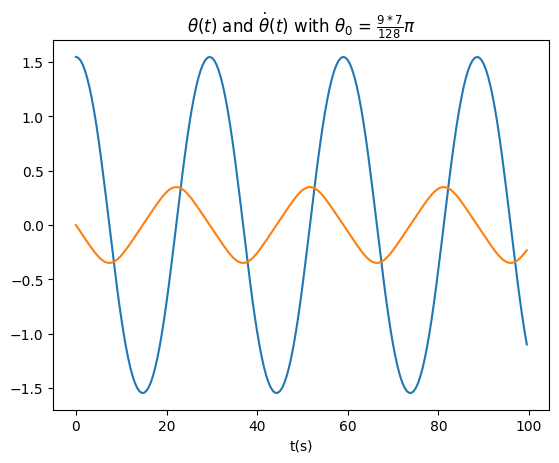

0.4921875π
Percent Error:
0.00038036085531763383


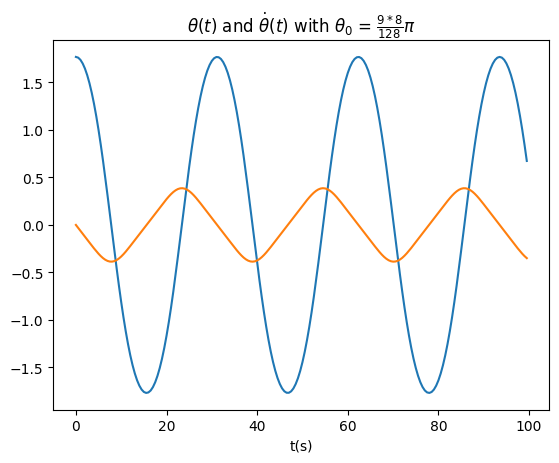

0.5625π
Percent Error:
0.0007455385529612858


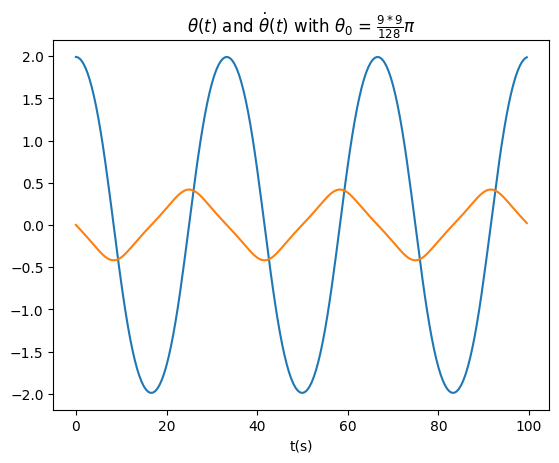

0.6328125π
Percent Error:
0.0010425450444549855


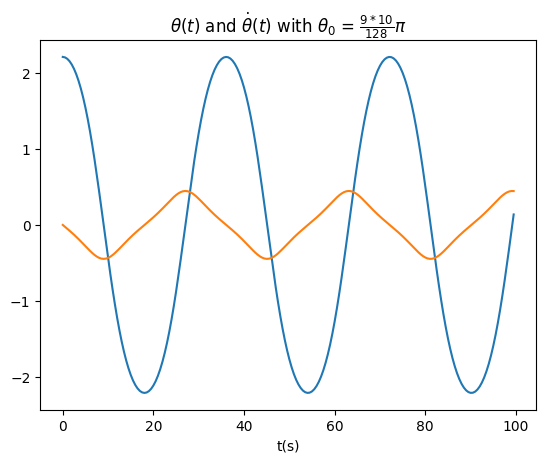

0.703125π
Percent Error:
0.0004554027936149985


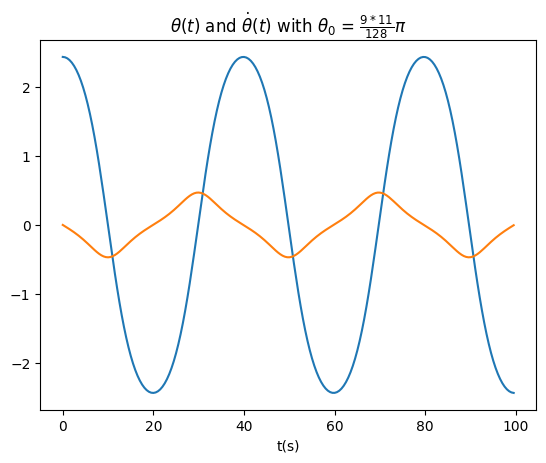

0.7734375π
Percent Error:
0.001042768682945816


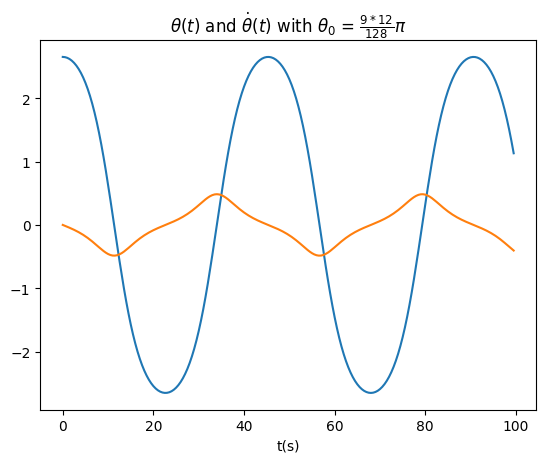

0.84375π
Percent Error:
0.002027202390364425


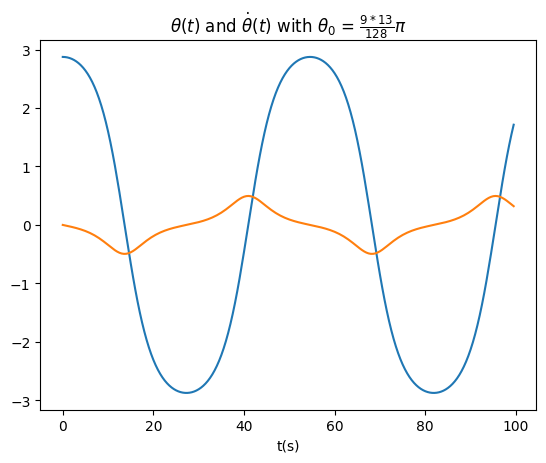

0.9140625π
Percent Error:
0.002056265705528684


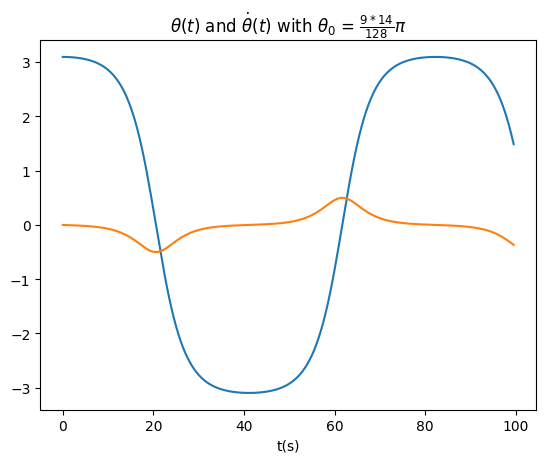

0.984375π
Percent Error:
0.0381118525620908


In [38]:
Gmatrix=[]
F_1=np.zeros(np.size(tt))
F_14=np.zeros(np.size(tt))
for i in range(0,n_trajectories):
    theta_0=i*theta_00+9*np.pi/(100*128) #intial theta for each trajectory
    m=np.sin(theta_0/2)**2 #contant for each trajectory
    K=integrate.quad(lambda z:((1-z**2)*(1-m*z**2))**(-1/2),0,1)[0] #parameter for each trajectory
    xt=solve_ivp(fx,t_span=(tt[0],tt[-1]),t_eval=tt,y0=([theta_0,0]),args=(omega_0,),vectorize=True, rtol=1e-20,method='DOP853')
    for j in range(np.size(tt)):
        F_theta[j]=2*np.arcsin(np.sin(theta_0/2)*sp.ellipj(K-omega_0*tt[j],(np.sin(theta_0/2)**2))[0])
        if i==1:
            F_1[j]=F_theta[j]
        if i==14:
            F_14[j]=F_theta[j]
        F_omega[j]=xt.y[1][j] #use numerical solution for omega[j]
        F_omegadot[j]=-omega_0**2*np.sin(F_theta[j])
    #plt.plot(tt,F_theta)
    #plt.show()
   
    theta0_str = f"$\\frac{{9 * {i}}}{{128}}\\pi$"
    plt.title(rf"$\theta(t)$ and $\dot{{\theta}}(t)$ with $\theta_0$ = {theta0_str}")
    #plt.plot(tt,F_theta)
    plt.plot(tt,xt.y[0])
    plt.plot(tt,F_omega)
    #plt.plot(tt,F_omegadot)
    plt.xlabel('t(s)')
    plt.show()
    print(f"{9*i/128}π")
    print("Percent Error:")
    #print(np.linalg.norm((xt.y[0,:] - F_theta[:]))/np.linalg.norm(F_theta[:])*100)
    print(np.linalg.norm((xt.y[0] - F_theta))/np.linalg.norm(F_theta)*100)
    G=np.column_stack([F_theta[:],F_omega[:]])
    Gmatrix.append(G) #create data matrix with number of samples, n_samples for each trajectory
Gmatrix=np.squeeze(np.stack(Gmatrix)) #Combine all trajectory data into one numpy array

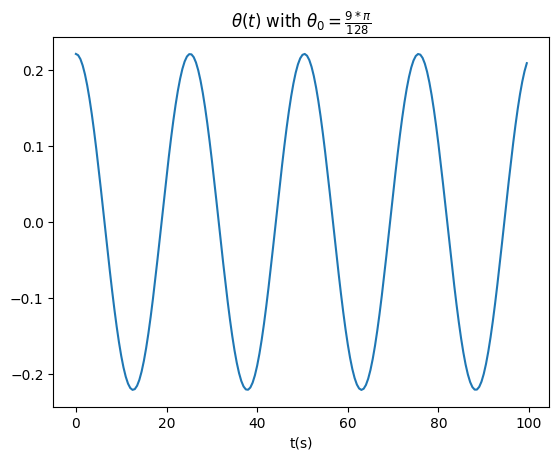

In [7]:
plt.plot(tt,F_1)
plt.title(r'$\theta(t)$ with $\theta_0=\frac{9*\pi}{128}$')
plt.xlabel('t(s)')
plt.show()

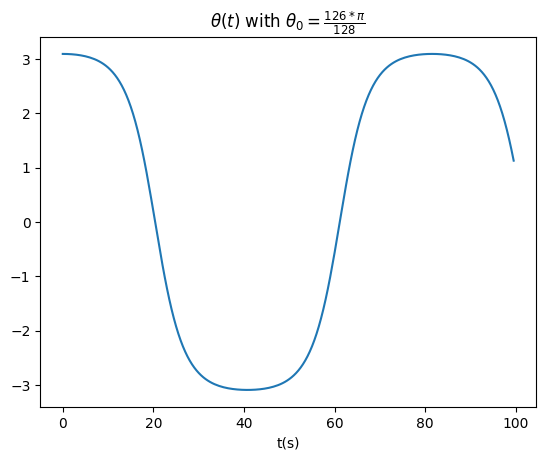

In [8]:
plt.plot(tt,F_14)
plt.title(r'$\theta(t)$ with $\theta_0=\frac{126*\pi}{128}$')
plt.xlabel('t(s)')
plt.show()

In [39]:
theGamma = 10

In [40]:
# TODO: Vectorize (and print the time for 1000 dimensional x, with as many as 10000 x and 10000 y)
# You will see orders of magnitude difference in run time.
def k(x,y,gamma=theGamma): #define kernel
     #return np.exp(-gamma*np.linalg.norm(x-y)**2)
     dist=sum(x**2)+sum(y**2)-2*np.dot(x,y)
     return np.exp(-gamma*dist)
     #return gamma*(np.exp(-2*(np.sin(np.linalg.norm(np.pi*(x-y)/20))**2)))

In [41]:

M=np.zeros([n_trajectories*(len(tt)-1),n_trajectories*(len(tt)-1)]) #Initialize M
for i in range(n_trajectories):
    for j in range(n_trajectories):
      for m in range(len(tt)-1):
        for n in range(len(tt)-1):
          k1 = k(Gmatrix[i,m,:],Gmatrix[j,n,:],gamma=theGamma)
          k2 = k(Gmatrix[i,m,:],Gmatrix[j,n+1,:],gamma=theGamma)
          k3 = k(Gmatrix[i,m+1,:],Gmatrix[j,n,:],gamma=theGamma)
          k4 = k(Gmatrix[i,m+1,:],Gmatrix[j,n+1,:],gamma=theGamma)
          M[m+(len(tt)-1)*i,n+(len(tt)-1)*j]=((tt[1]-tt[0])**2/4)*(k1+k2+k3+k3)

In [13]:
i_arr=np.arange(n_trajectories)
j_arr=np.arange(n_trajectories)
m_arr=np.arange(len(tt)-1)
n_arr=np.arange(len(tt)-1)

i_grid,j_grid_k_grid,m_grid,n_grid = np.meshgrid(i_arr,j_arr,m_arr,n_arr)
K1 = K(Gmatrix[i_grid,m_grid,:],Gmatrix[j_grid,n_grid,:],gamma=theGamma)
shift=1
n_shifted=np.roll(n_grid,shift,axis=3)
K2 = K(Gmatrix[i_grid,m_grid,:],Gmatrix[j_grid,n_shifted,:],gamma=theGamma)
m_shifted=np.roll(n_grid,shift,axis=2)
K3 = K(Gmatrix[i_grid,m_shifted,:],Gmatrix[j_shifted,n_grid,:],gamma=theGamma)
K4 = K(Gmatrix[i_grid,m_shifted,:],Gmatrix[j_grid,n_shifted,:],gamma=theGamma)





NameError: name 'j_grid' is not defined

In [42]:
d=2
#delta=(Gmatrix[:,-1]-Gmatrix[:,0]).reshape(d*n_trajectories,1)
delta = np.zeros([d*n_trajectories*(len(tt)-1)])
for i in range(n_trajectories):
  for m in range(len(tt)-1):
    delta[(m+(len(tt)-1)*i)*d:(m+(len(tt)-1)*i+1)*d]=Gmatrix[i,m+1,:]-Gmatrix[i,m,:]

Marray=np.kron(M,np.identity(d))

In [43]:

l=.0000005 #regularization hyperparmeter.
Mplus=Marray+l*n_trajectories*(len(tt)-1)*np.identity(d*n_trajectories*(len(tt)-1)) #create modified M.
alpha=np.linalg.solve(Mplus,delta)#solve linear system for alpha.
#alphamatrix=alpha.reshape(n_trajectories*(len(tt)-1),d,order='F') #reshape alpha so that alpha[i] has is 1xd

In [44]:
slopes = (Gmatrix[:,1:,:] - Gmatrix[:,:-1,:])/(tt[1]-tt[0])

In [45]:
def fstar(t,y,Gmatrix,alpha,tspan,d):
    matrix = np.zeros([d,d*n_trajectories*(len(tt)-1)])
    for i in range(n_trajectories):
      for m in range(len(tt)-1):
        matrix[:,(m+(len(tt)-1)*i)*d:(m+(len(tt)-1)*i + 1)*d] = (tspan/2)*(k(y,Gmatrix[i,m,:])+k(y,Gmatrix[i,m+1,:]))*np.identity(d)
    return matrix@alpha

In [46]:
predicted_matrix = np.zeros((slopes.shape[0],len(tt)-1,slopes.shape[-1]))
for i in range(n_trajectories):
  for m in range(len(tt)-1):
    y = Gmatrix[i,m,:]
    predicted_slope = fstar(0,y,Gmatrix,alpha,tt[1]-tt[0],d)
    predicted_matrix[i,m,:] = predicted_slope


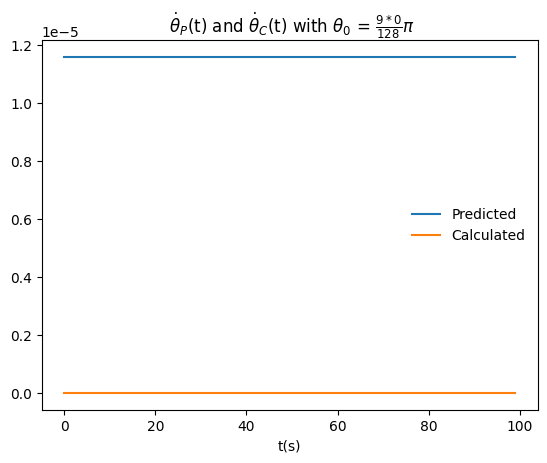

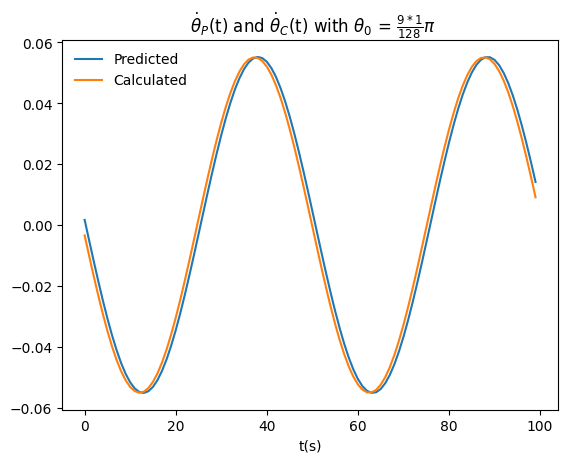

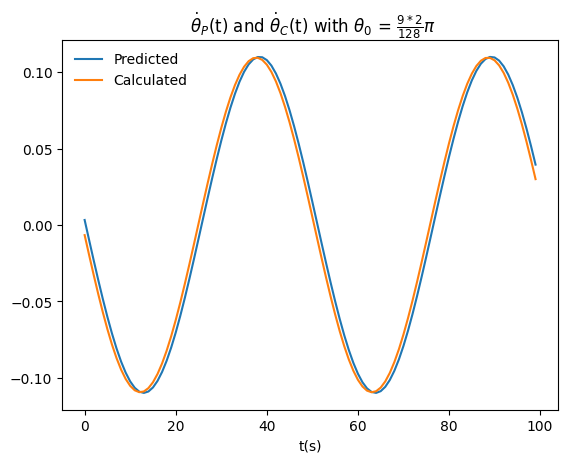

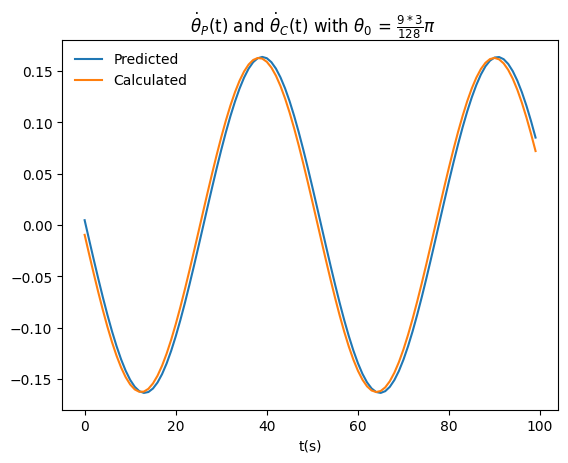

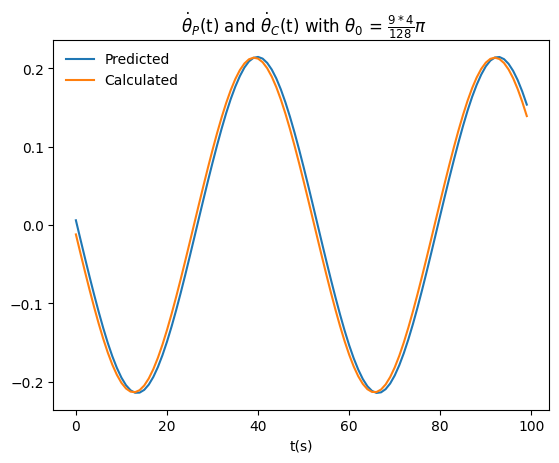

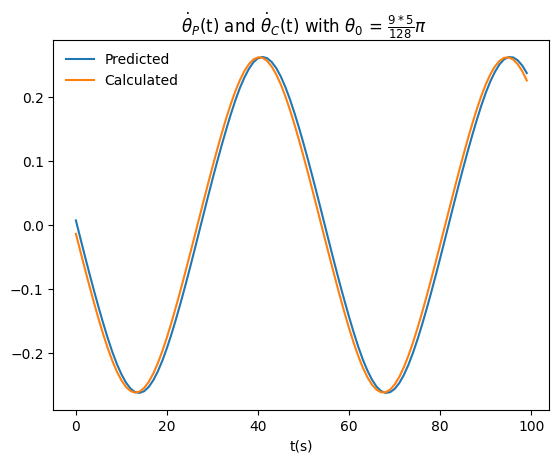

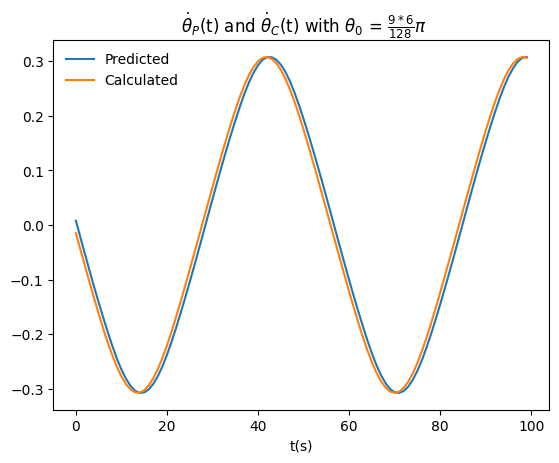

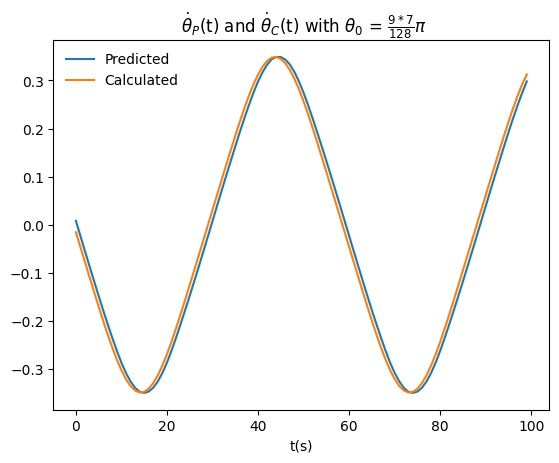

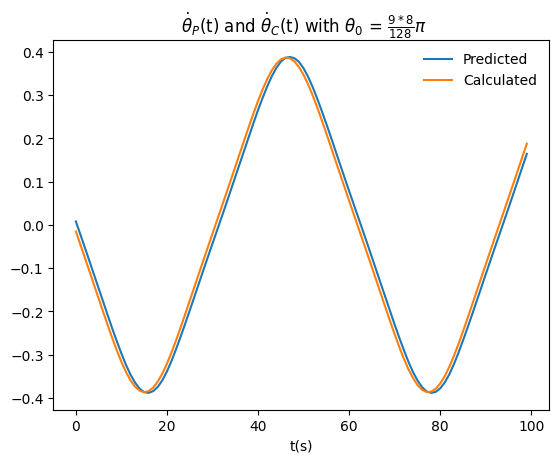

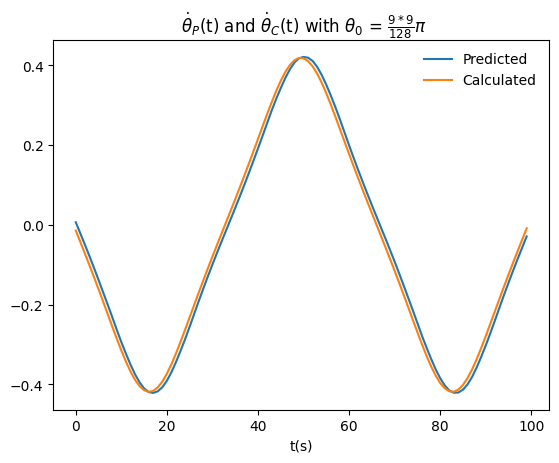

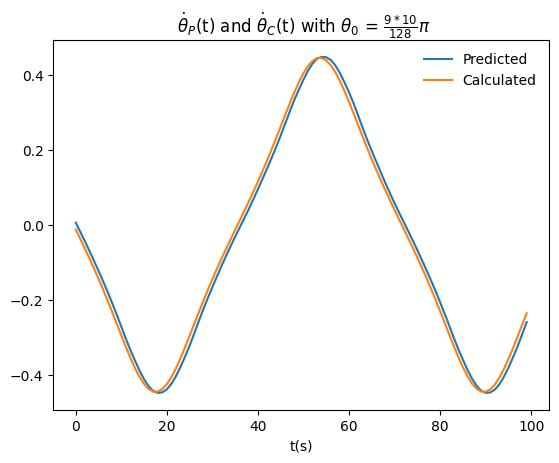

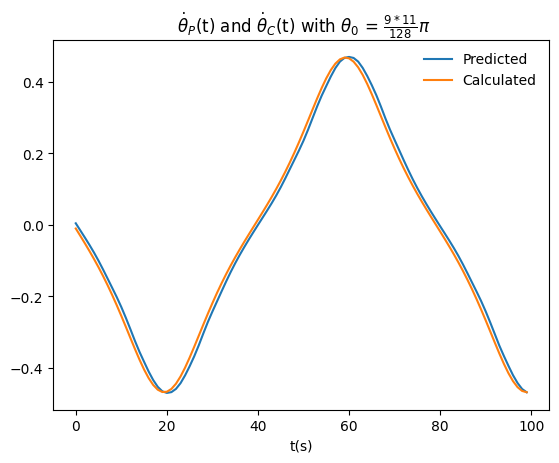

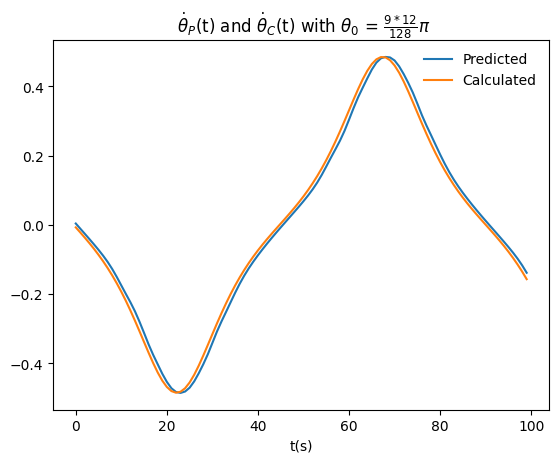

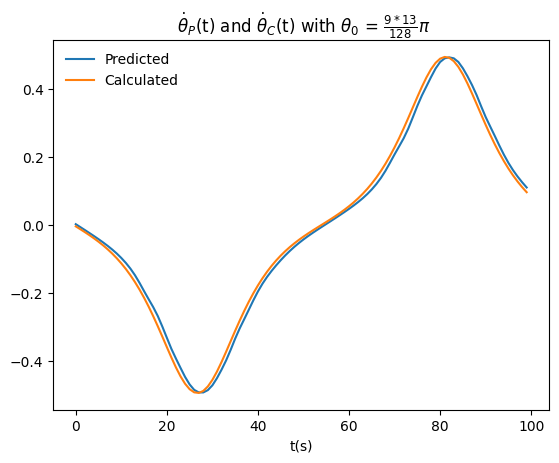

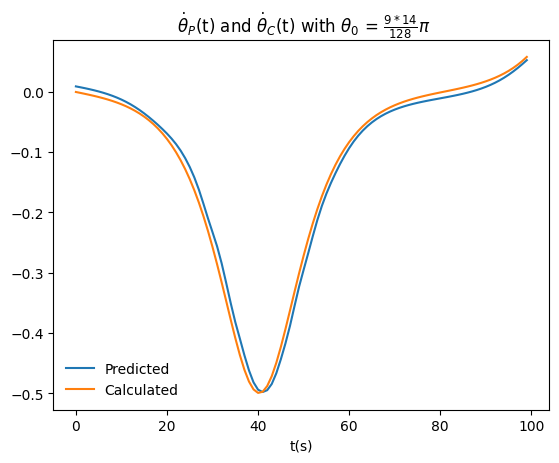

In [97]:
for i in range(n_trajectories):
    plt.plot(predicted_matrix[i, :100, 0], label='Predicted')
    plt.plot(slopes[i,:100,0], label='Calculated')

    theta0_str = f"$\\frac{{9 * {i}}}{{128}} \\pi$"
    theta_P = r"$\dot{\theta}_P$"
    theta_C = r"$\dot{\theta}_C$"
    plt.title(rf" {theta_P}(t) and {theta_C}(t) with $\theta_0$ = {theta0_str}")

    plt.xlabel("t(s)")
    plt.legend(loc='best', frameon=False)
    plt.show()

In [93]:
np.shape(slopes)

(15, 199, 2)

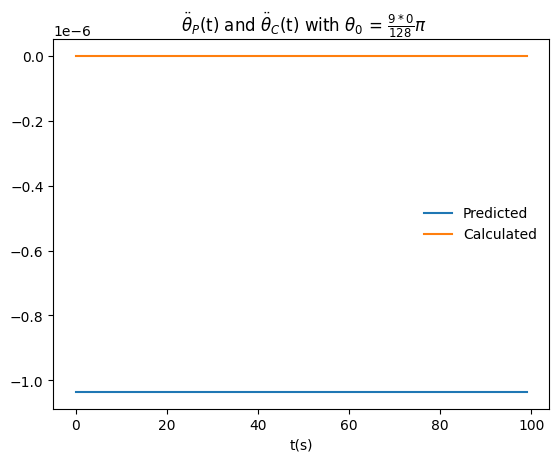

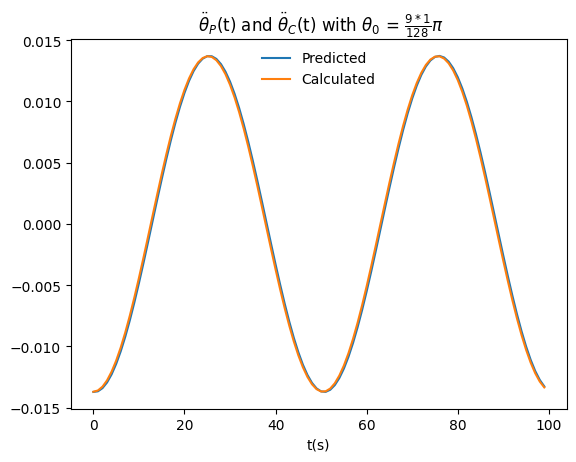

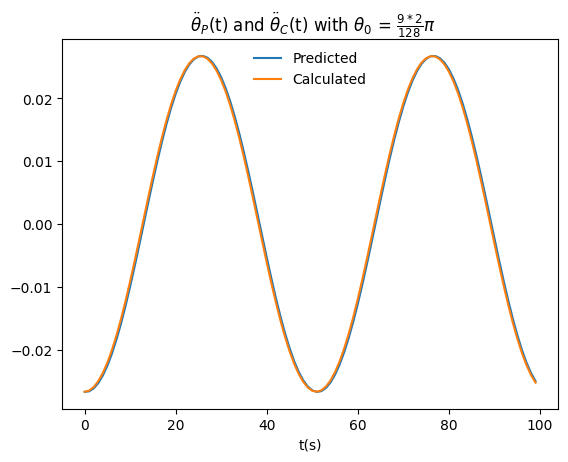

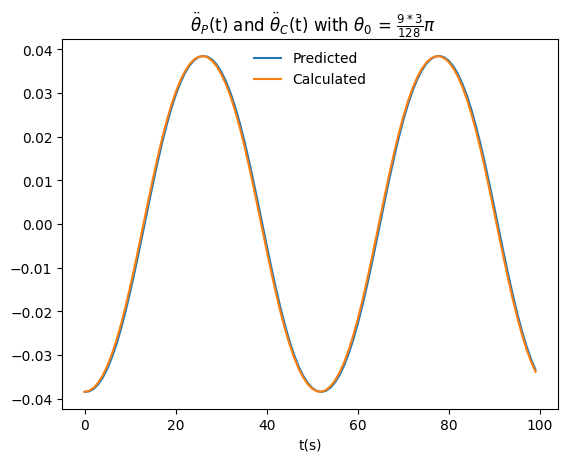

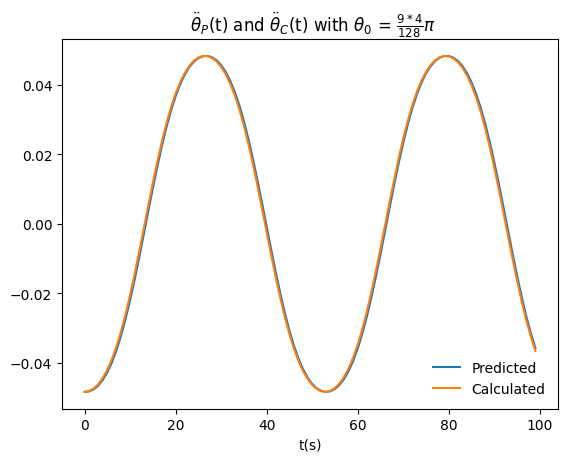

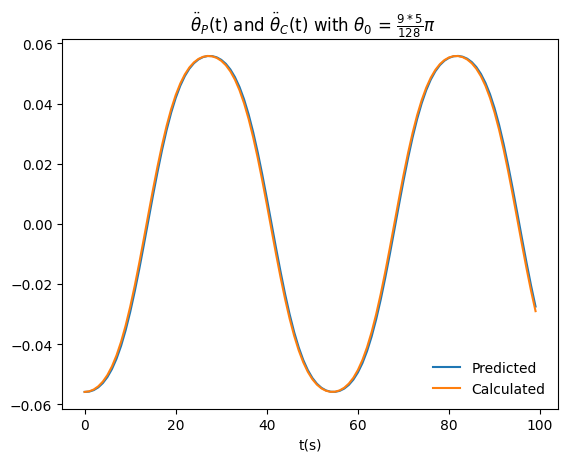

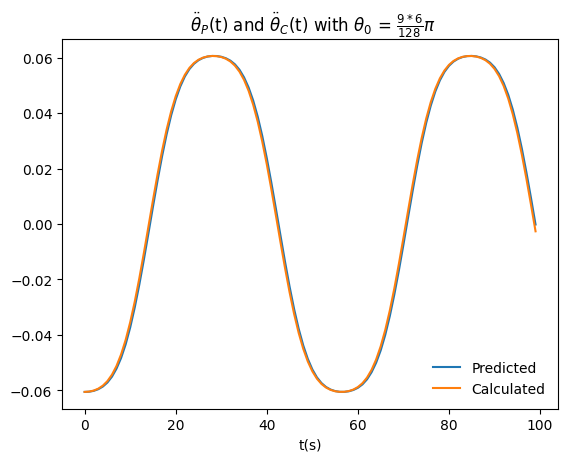

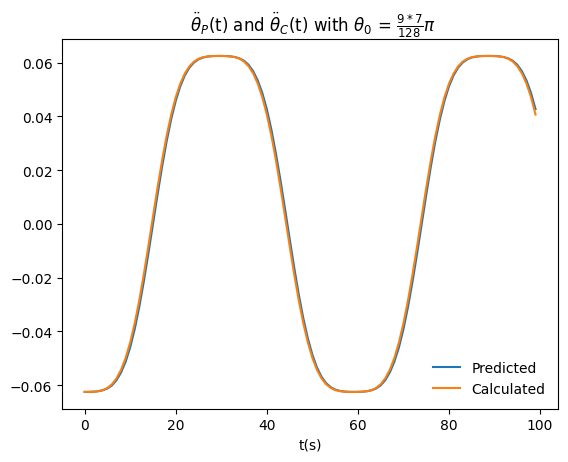

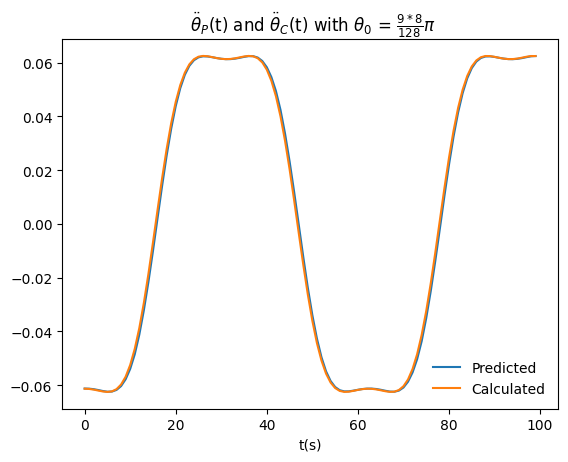

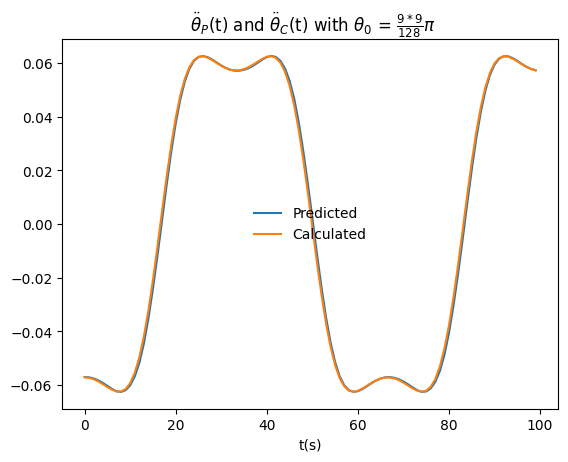

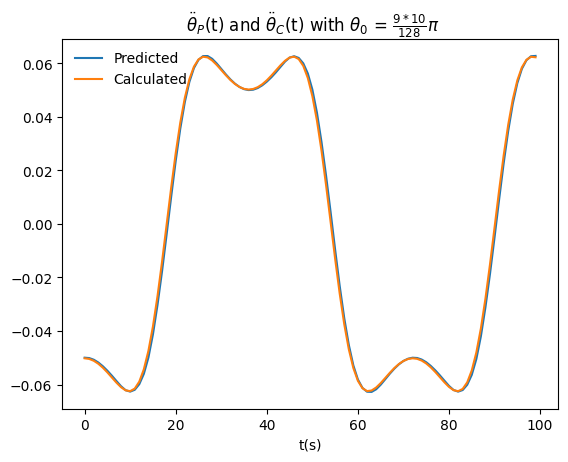

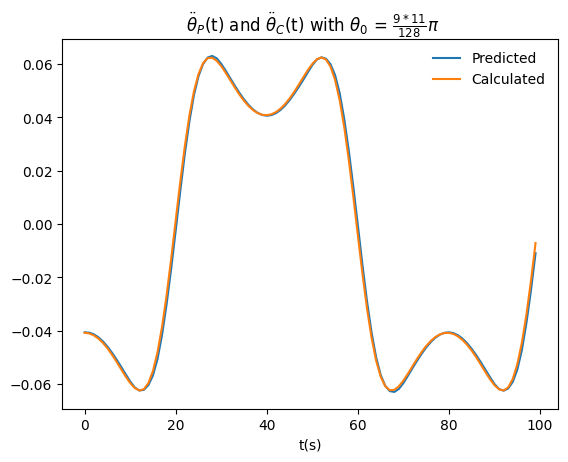

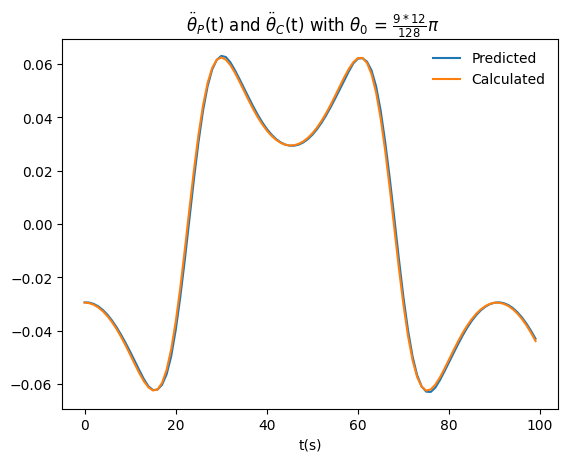

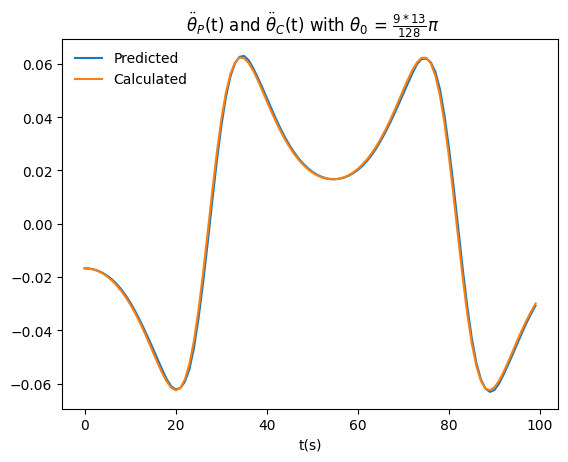

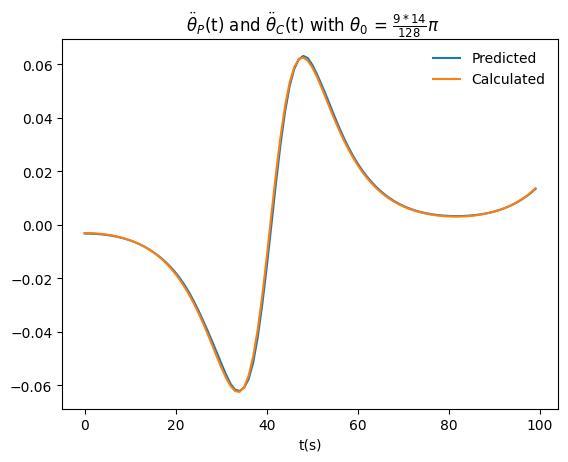

In [91]:
for i in range(n_trajectories):
    plt.plot(predicted_matrix[i, :100, 1], label='Predicted')
    plt.plot(-omega_0**2 * np.sin(Gmatrix[i, :100, 0]), label='Calculated')

    theta0_str = f"$\\frac{{9 * {i}}}{{128}} \\pi$"
    theta_P = r"$\ddot{\theta}_P$"
    theta_C = r"$\ddot{\theta}_C$"
    plt.title(rf" {theta_P}(t) and {theta_C}(t) with $\theta_0$ = {theta0_str}")

    plt.xlabel("t(s)")
    plt.legend(loc='best', frameon=False)
    plt.show()

In [60]:
y_0=Gmatrix[:,0,:]

In [61]:
    #def k(x,y,gamma=.01):
    #     return np.exp(-gamma*np.linalg.norm(x-y)**2)

#def fstar(t,y,Gmatrix,alphamatrix,tspan,n_examples,d):
#    def k(x,y,gamma=.01):
#         return np.exp(-gamma*np.linalg.norm(x-y)**2)
#         #return gamma*(np.exp(-2*(np.sin(np.linalg.norm(np.pi*(x-y)/20))**2)))
#    sol=0
#    for i in range(n_examples):
#        #sol=sol+(tspan/2)*(k(y,Gmatrix[i,0])+k(y,Gmatrix[i,-1]))*alphamatrix[i]
#        sol=sol+(tspan/2)*(k(y,Gmatrix[i,0,:])+k(y,Gmatrix[i,-1,:]))*np.identity(d)@np.transpose(alphamatrix[i,:])
#    return sol
sol=np.zeros([n_trajectories,len(tt),d])
for i in range(n_trajectories):
#stop=2
#for i in range(stop):
  trajs=solve_ivp(fstar,t_span=(tt[0],tt[-1]),t_eval=tt,y0=y_0[i,:],args=(Gmatrix,alpha,tt[1]-tt[0],d),method='RK45',rtol=1e-14)
  #trajs = euler(fstar,y_0[i,:],tt[0],(tt[1]-tt[0])/2,100,Gmatrix,alpha,tt[1]-tt[0],d)
  #trajs= euler(fstar,y_0[i,:],tt[0],tt[1]-tt[0],len(tt),Gmatrix,alpha,tt[1]-tt[0],d)
  sol[i,:]=(trajs.y).T
 

/opt/anaconda3/lib/python3.9/site-packages/scipy/integrate/_ivp/common.py:47: UserWarning: At least one element of `rtol` is too small. Setting `rtol = np.maximum(rtol, 2.220446049250313e-14)`.
  warn("At least one element of `rtol` is too small. "


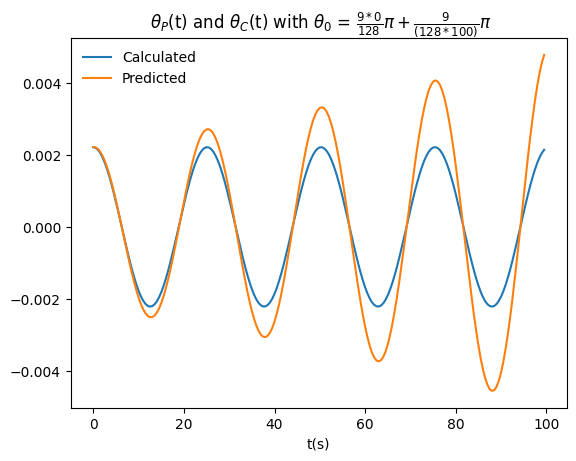

0.0π+9/(128*100)π


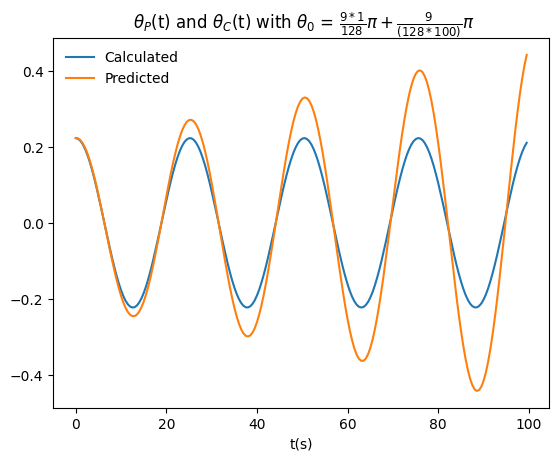

0.0703125π+9/(128*100)π


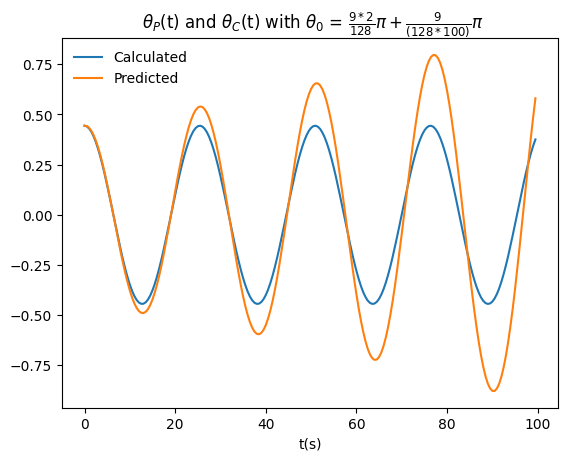

0.140625π+9/(128*100)π


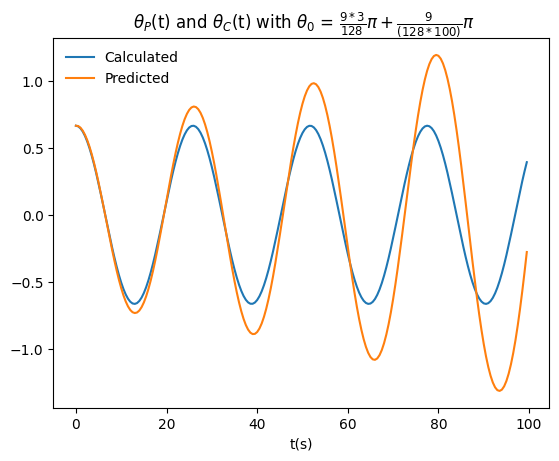

0.2109375π+9/(128*100)π


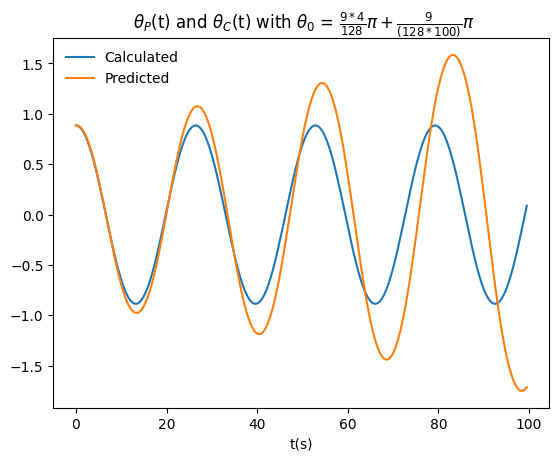

0.28125π+9/(128*100)π


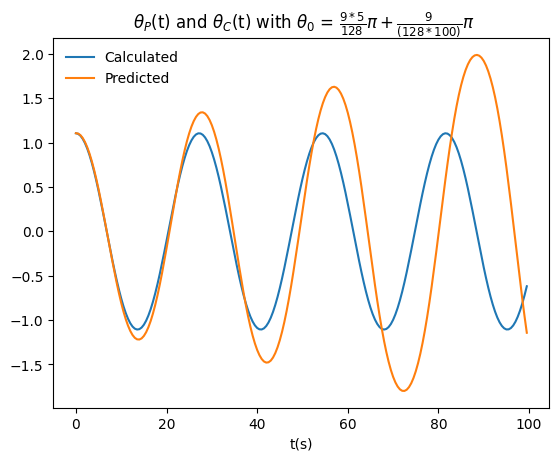

0.3515625π+9/(128*100)π


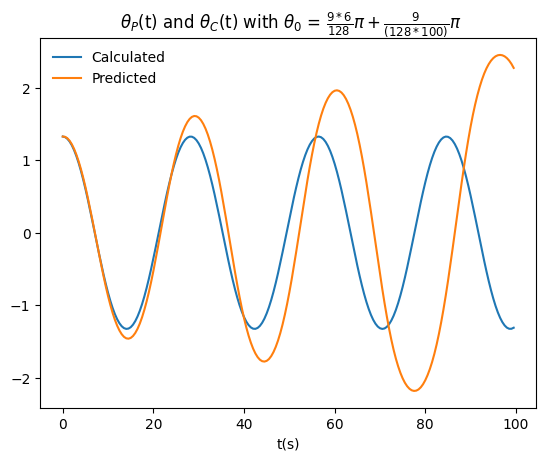

0.421875π+9/(128*100)π


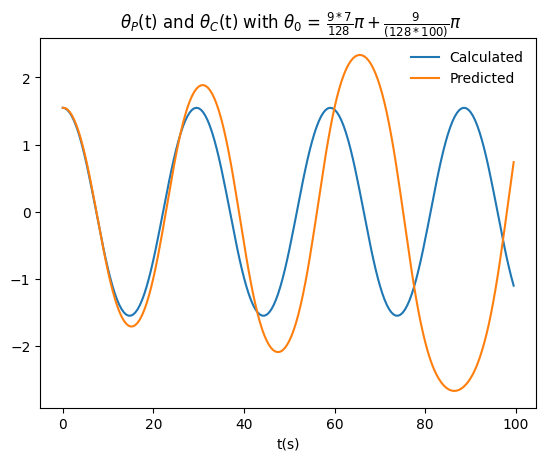

0.4921875π+9/(128*100)π


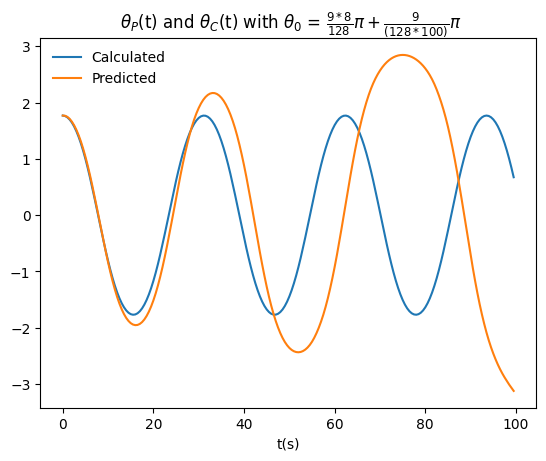

0.5625π+9/(128*100)π


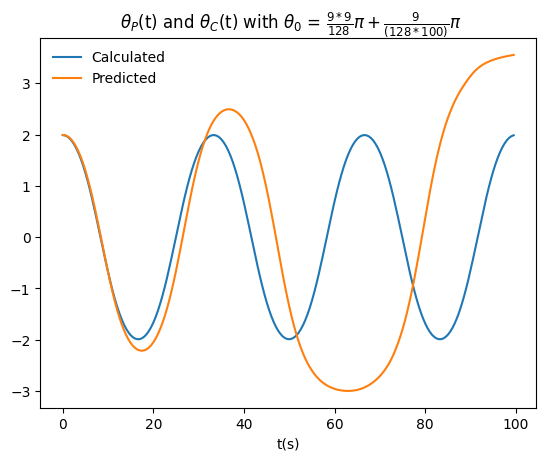

0.6328125π+9/(128*100)π


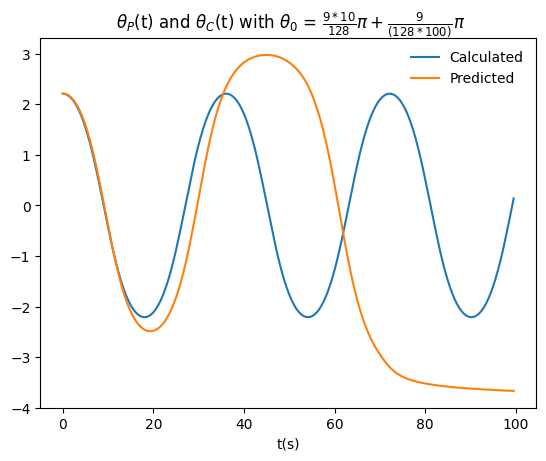

0.703125π+9/(128*100)π


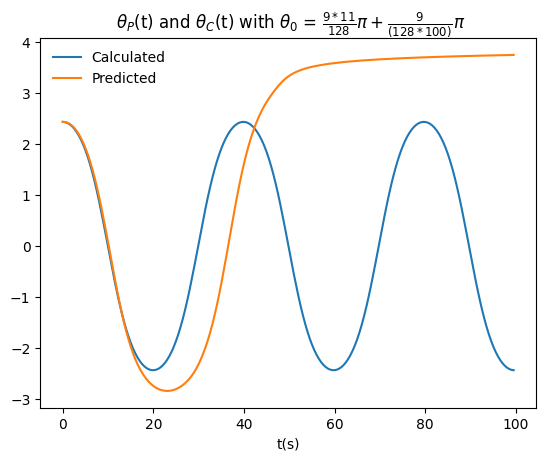

0.7734375π+9/(128*100)π


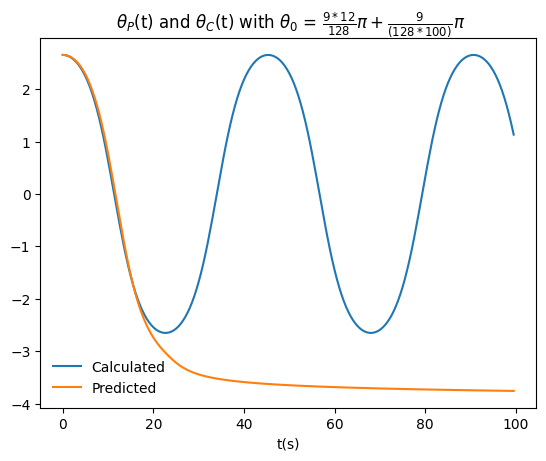

0.84375π+9/(128*100)π


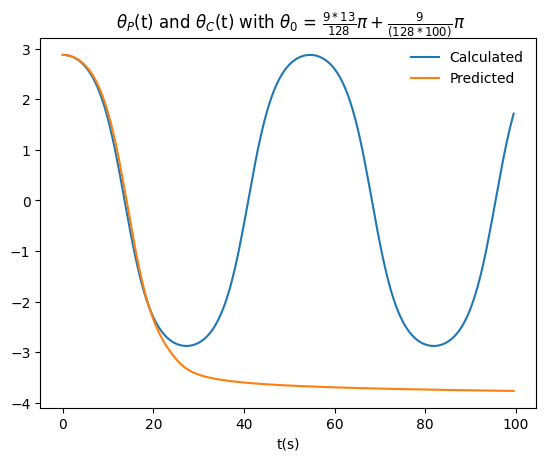

0.9140625π+9/(128*100)π


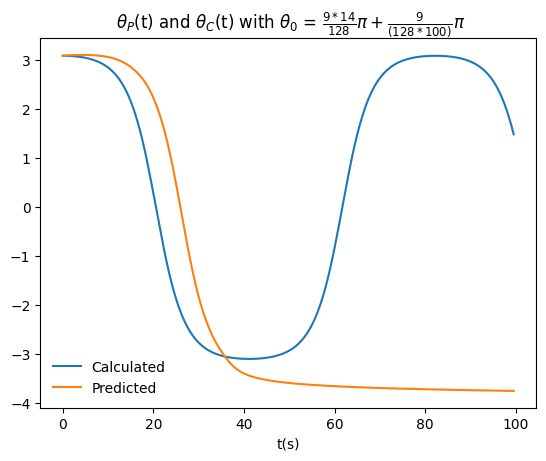

0.984375π+9/(128*100)π


In [62]:
for i in range(n_trajectories):

  plt.plot(tt,Gmatrix[i,:,0],label='Calculated')
  plt.plot(tt,sol[i,:,0],label='Predicted')
  theta0_str = f"$\\frac{{9 * {i}}}{{128}}\\pi+\\frac{{9}}{{(128*100)}}\\pi$"
  theta_P = r"${\theta}_P$"
  theta_C = r"${\theta}_C$"
  plt.title(rf" {theta_P}(t) and {theta_C}(t) with $\theta_0$ = {theta0_str}")
  plt.xlabel('t(s)')
  plt.legend(loc='best',frameon=False)
  plt.show()
  print(f"{9*i/128}π+9/(128*100)π")

In [63]:
tn=5
testy_0=np.column_stack([np.pi*np.random.uniform(0,1,tn).T,np.zeros([tn,1])])
trajs_A=np.zeros(len(tt))

In [ ]:

sol=np.zeros([tn,len(tt),d])
for i in range(tn):
#stop=2
#for i in range(stop):
  trajs=solve_ivp(fstar,t_span=(tt[0],tt[-1]),t_eval=tt,y0=testy_0[i,:],args=(Gmatrix,alpha,tt[1]-tt[0],d),method='RK45',rtol=1e-14)
  #trajs = euler(fstar,y_0[i,:],tt[0],(tt[1]-tt[0])/2,100,Gmatrix,alpha,tt[1]-tt[0],d)
  #trajs= euler(fstar,y_0[i,:],tt[0],tt[1]-tt[0],len(tt),Gmatrix,alpha,tt[1]-tt[0],d)
  sol[i,:]=(trajs.y).T

/opt/anaconda3/lib/python3.9/site-packages/scipy/integrate/_ivp/common.py:47: UserWarning: At least one element of `rtol` is too small. Setting `rtol = np.maximum(rtol, 2.220446049250313e-14)`.
  warn("At least one element of `rtol` is too small. "


/opt/anaconda3/lib/python3.9/site-packages/scipy/integrate/_ivp/common.py:47: UserWarning: At least one element of `rtol` is too small. Setting `rtol = np.maximum(rtol, 2.220446049250313e-14)`.
  warn("At least one element of `rtol` is too small. "


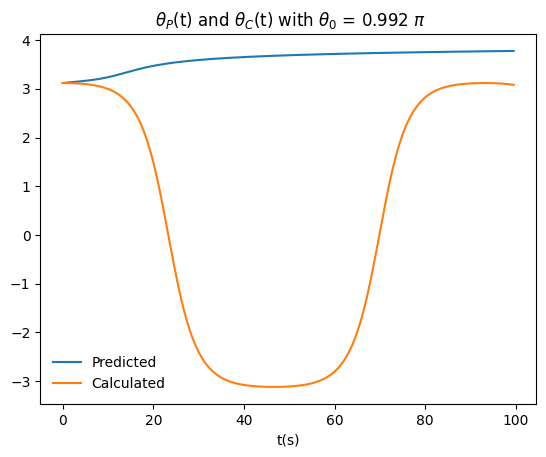

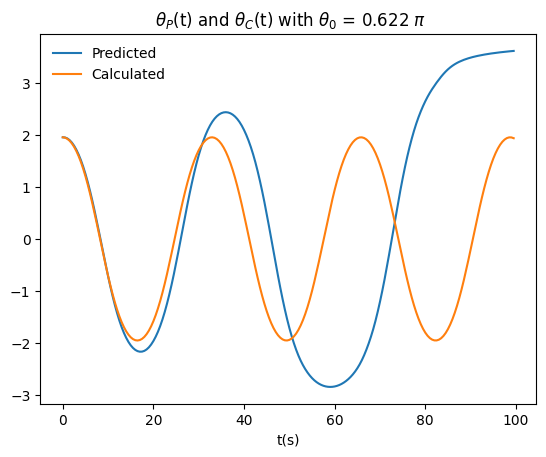

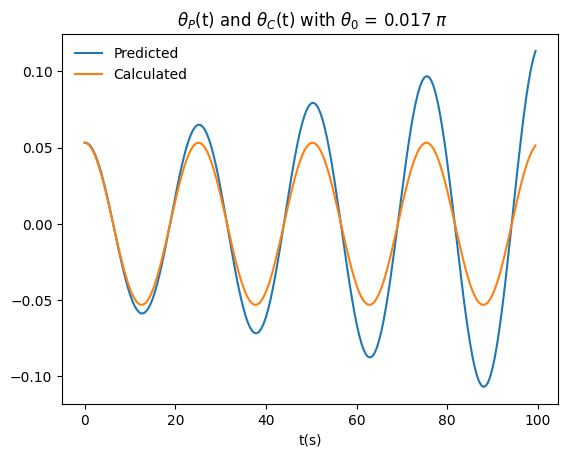

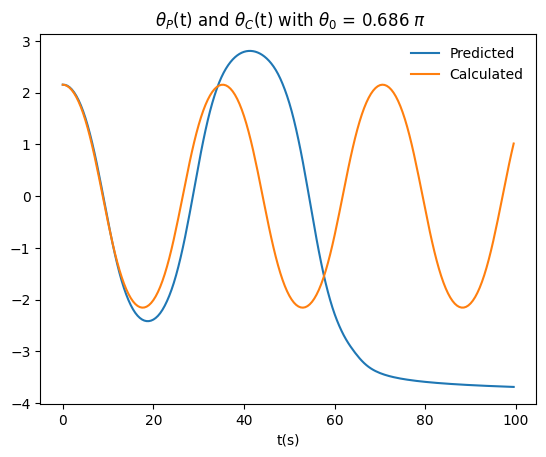

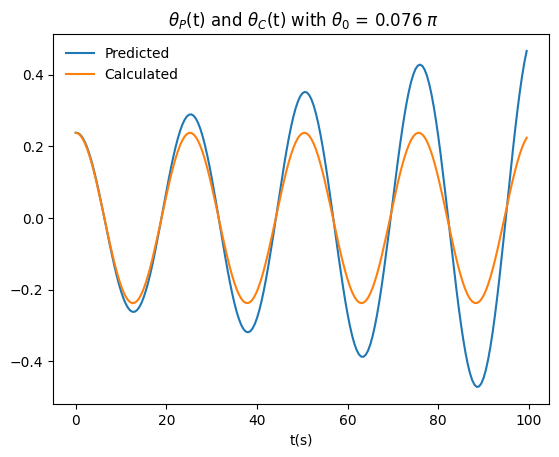

In [73]:

for i in range(tn):
    trajs_M=solve_ivp(fstar,t_span=(tt[0],tt[-1]),t_eval=tt,y0=testy_0[i],args=(Gmatrix,alpha,tt[1]-tt[0],d),method='RK45',rtol=1e-14)
    plt.plot(tt,trajs_M.y[0],label='Predicted')
    m=np.sin(testy_0[i,0]/2)**2 #contant for each trajectory
    K=integrate.quad(lambda z:((1-z**2)*(1-m*z**2))**(-1/2),0,1)[0] #parameter for each trajectory
    for j in range(np.size(tt)):
        trajs_A[j]=2*np.arcsin(np.sin(testy_0[i,0]/2)*sp.ellipj(K-omega_0*tt[j],(np.sin(testy_0[i,0]/2)**2))[0])
    plt.plot(tt,trajs_A,label='Calculated')
    plt.xlabel('t(s)')
    plt.legend(loc='best',frameon=False)
    theta_P = r"${\theta}_P$"
    theta_C = r"${\theta}_C$"
    testy=np.round(testy_0[i,0]/np.pi,3)
    theta0_str=f"{testy} $\pi$"
    plt.title(rf" {theta_P}(t) and {theta_C}(t) with $\theta_0$ = {theta0_str}")
    plt.show()


    
                                                         

In [81]:
sol=np.zeros([tn,len(tt),d])
for i in range(tn):
#stop=2
#for i in range(stop):
  trajs=solve_ivp(fstar,t_span=(tt[0],tt[-1]),t_eval=tt,y0=testy_0[i,:],args=(Gmatrix,alpha,tt[1]-tt[0],d),method='LSODA',rtol=1e-14)
  #trajs = euler(fstar,y_0[i,:],tt[0],(tt[1]-tt[0])/2,100,Gmatrix,alpha,tt[1]-tt[0],d)
  #trajs= euler(fstar,y_0[i,:],tt[0],tt[1]-tt[0],len(tt),Gmatrix,alpha,tt[1]-tt[0],d)
  sol[i,:]=(trajs.y).T

/opt/anaconda3/lib/python3.9/site-packages/scipy/integrate/_ivp/common.py:47: UserWarning: At least one element of `rtol` is too small. Setting `rtol = np.maximum(rtol, 2.220446049250313e-14)`.
  warn("At least one element of `rtol` is too small. "


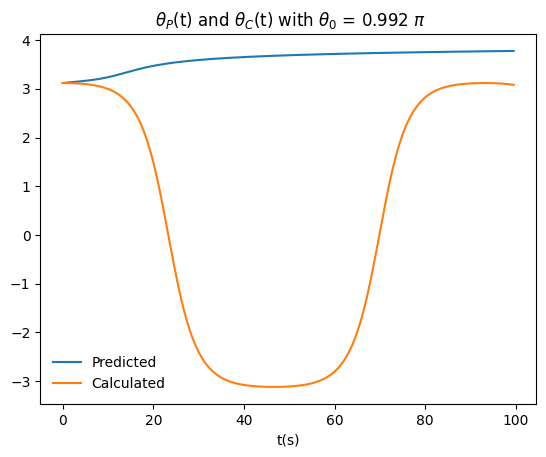

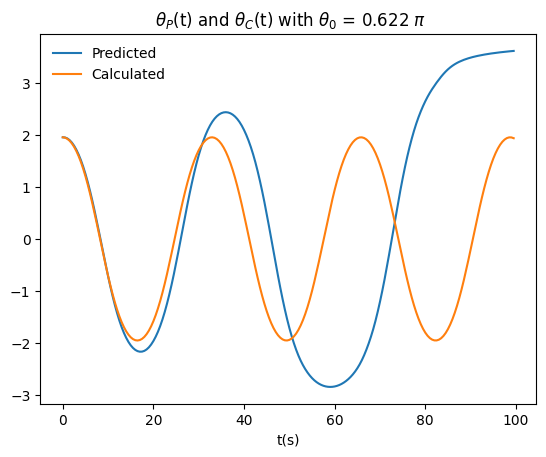

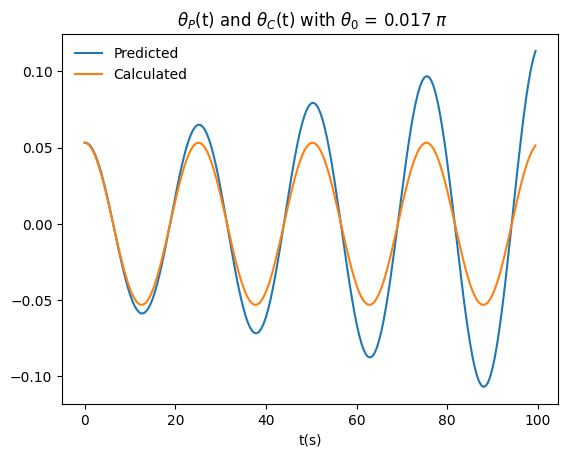

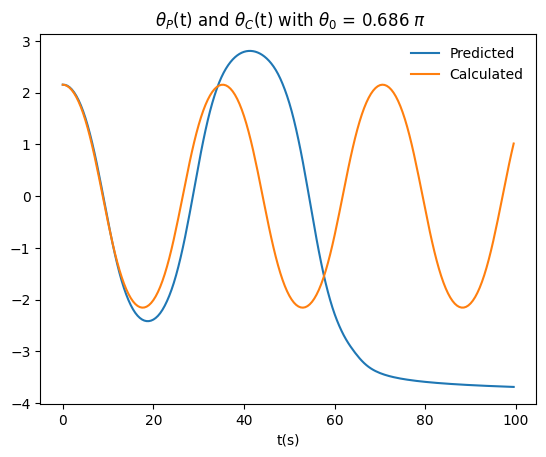

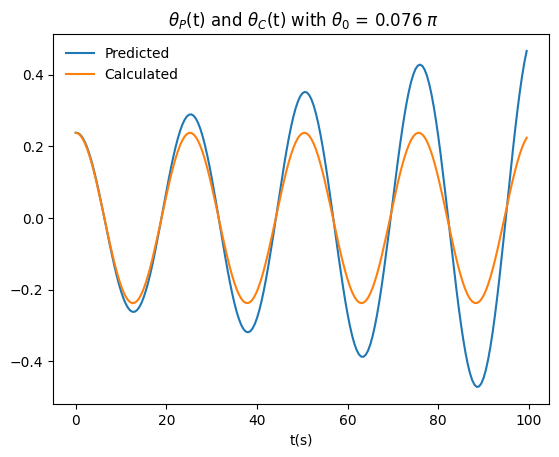

In [84]:
for i in range(tn):
    trajs_M=solve_ivp(fstar,t_span=(tt[0],tt[-1]),t_eval=tt,y0=testy_0[i],args=(Gmatrix,alpha,tt[1]-tt[0],d),method='RK45',rtol=1e-14)
    plt.plot(tt,trajs_M.y[0],label='Predicted')
    m=np.sin(testy_0[i,0]/2)**2 #contant for each trajectory
    K=integrate.quad(lambda z:((1-z**2)*(1-m*z**2))**(-1/2),0,1)[0] #parameter for each trajectory
    for j in range(np.size(tt)):
        trajs_A[j]=2*np.arcsin(np.sin(testy_0[i,0]/2)*sp.ellipj(K-omega_0*tt[j],(np.sin(testy_0[i,0]/2)**2))[0])
    plt.plot(tt,trajs_A,label='Calculated')
    plt.xlabel('t(s)')
    plt.legend(loc='best',frameon=False)
    theta_P = r"${\theta}_P$"
    theta_C = r"${\theta}_C$"
    testy=np.round(testy_0[i,0]/np.pi,3)
    theta0_str=f"{testy} $\pi$"
    plt.title(rf" {theta_P}(t) and {theta_C}(t) with $\theta_0$ = {theta0_str}")
    plt.show()



In [83]:
%store

Stored variables and their in-db values:


In [85]:
print(9/(12800))

0.000703125


In [86]:
print(9*14/128+9/12800)

0.985078125


In [87]:
%store

Stored variables and their in-db values:
